<a href="https://colab.research.google.com/github/IshanRavishankar15/23FE10CSE00641-ML/blob/main/Lab7_Decision_Tree_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7
##Decision Tree Classifier

Aim : Implement Decision Tree Classification on the Parkinsons dataset

In [ ]:
# Import libraries for data handling, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Load Parkinson's dataset
df = pd.read_csv("parkinsons.csv")

# Display first 5 rows
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
# Display dataset information and statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
# Check distribution of target variable
df['status'].value_counts()

,count
status,
1,147
0,48


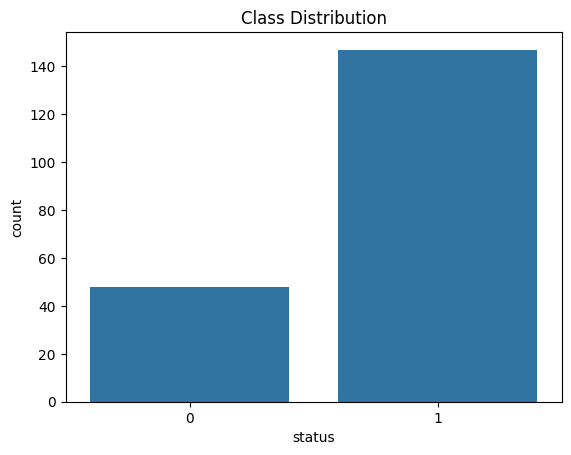

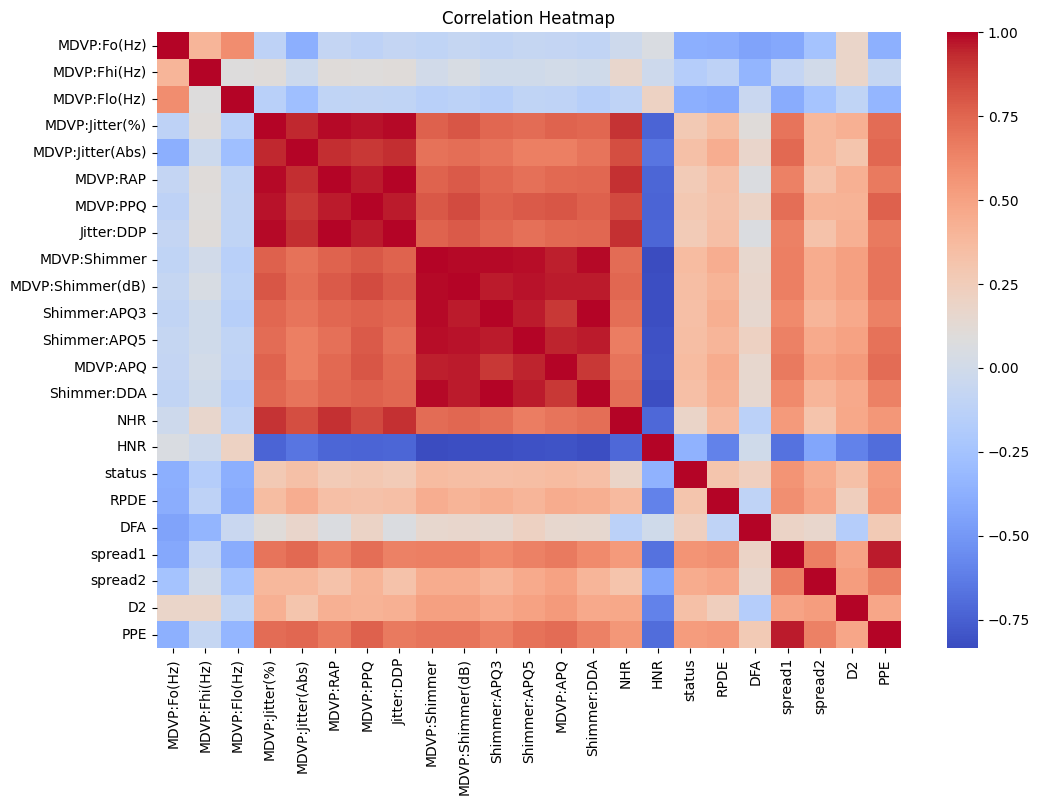

In [ ]:
# Plot class distribution
sns.countplot(x='status', data=df)
plt.title("Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.drop('name', axis=1).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

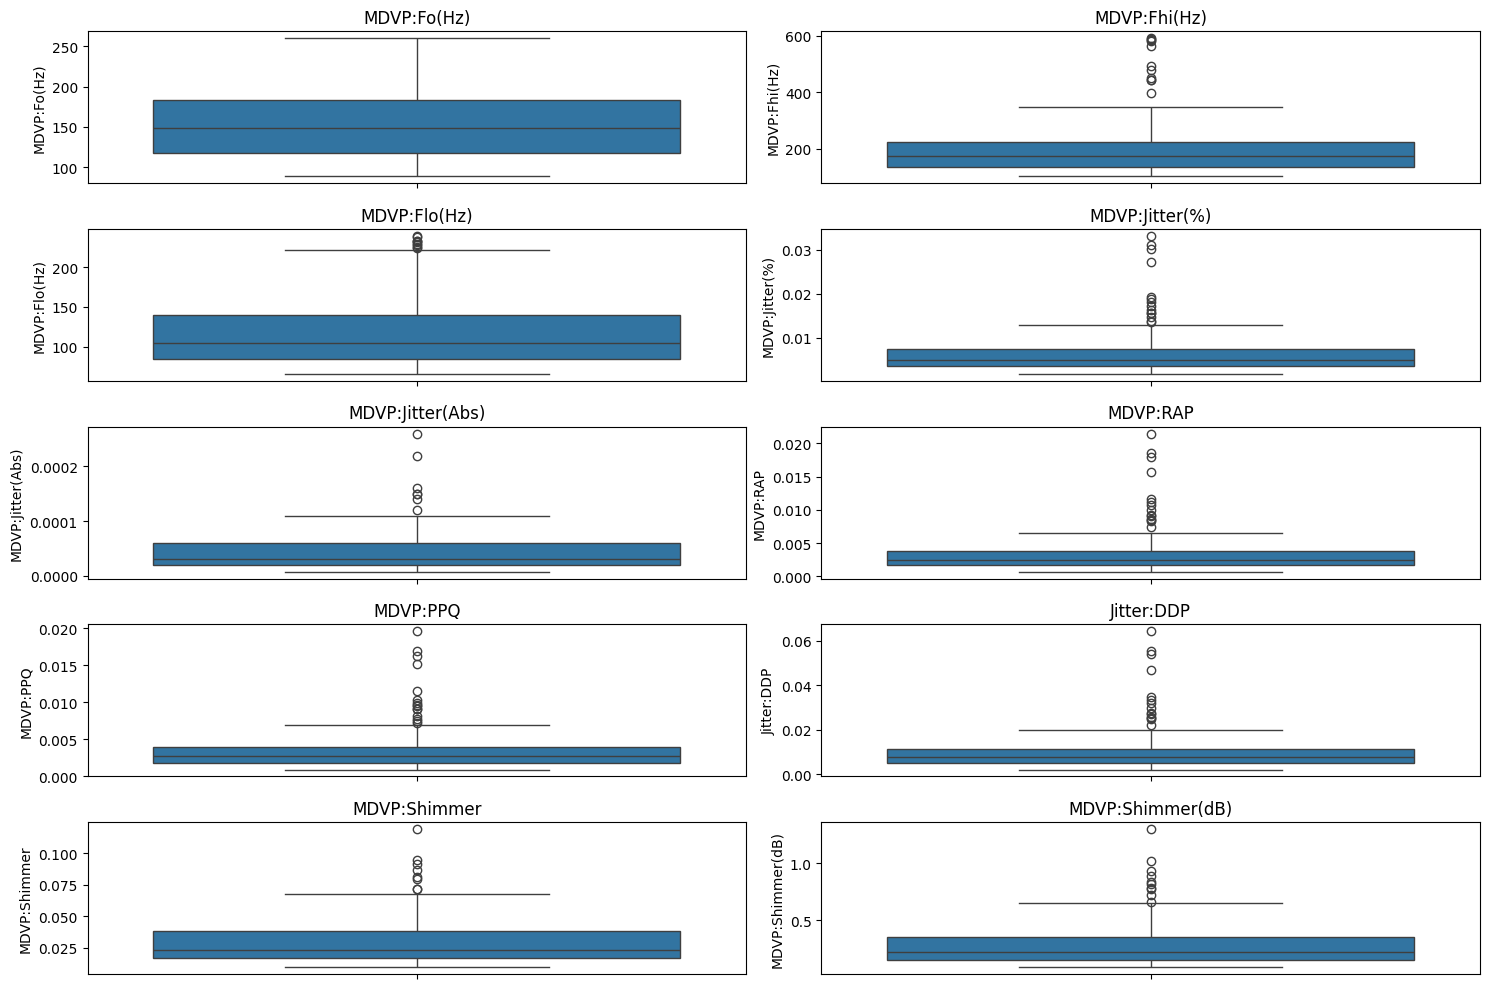

In [ ]:
# Select first 10 features excluding name and status
features = df.drop(['name','status'], axis=1).columns[:10]

plt.figure(figsize=(15,10))

for i, col in enumerate(features,1):
    plt.subplot(5,2,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Define feature matrix and target variable
X = df.drop(['name','status'], axis=1)
y = df['status']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [ ]:
# Scale features for better model performance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train Decision Tree classifier
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

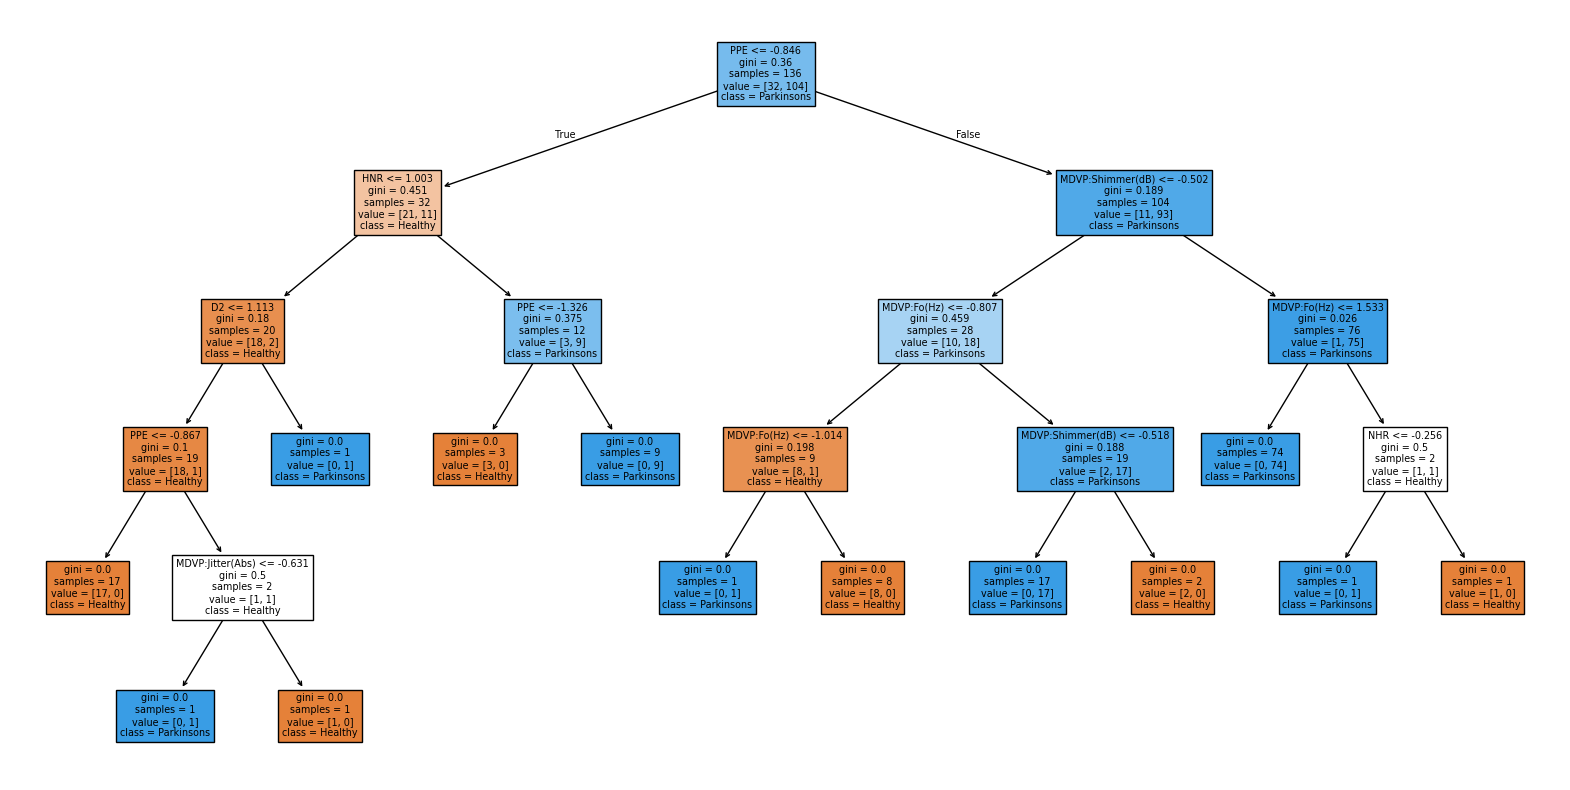

In [ ]:
# Plot the trained decision tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=["Healthy","Parkinsons"], filled=True)
plt.show()

In [ ]:
# Predict class labels for test data
predictions = dt_model.predict(X_test)

In [ ]:
# Display confusion matrix and classification report
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[13  3]
 [ 3 40]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.93      0.93      0.93        43

    accuracy                           0.90        59
   macro avg       0.87      0.87      0.87        59
weighted avg       0.90      0.90      0.90        59



In [ ]:
# Define parameter grid for optimization
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, refit=True, verbose=2)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=   0.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=   0.0s
[CV] END ..criterion=gini, max_depth=3, min_samples_split=10; total time=   0.0s
[CV] END ..criterion=gini, max_depth=3, min_sam

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10]},
             verbose=2)

In [ ]:
# Display best parameters
grid.best_params_

{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}

In [ ]:
# Predict using optimized model
grid_predictions = grid.predict(X_test)

In [ ]:
# Evaluate optimized model
print(confusion_matrix(y_test, grid_predictions))
print(classification_report(y_test, grid_predictions))

[[12  4]
 [ 6 37]]
              precision    recall  f1-score   support

           0       0.67      0.75      0.71        16
           1       0.90      0.86      0.88        43

    accuracy                           0.83        59
   macro avg       0.78      0.81      0.79        59
weighted avg       0.84      0.83      0.83        59

